Question 2: Image Enhancement and Thresholding

An image named low_contrast.png is difficult to see. Your task is to enhance it and then segment it.

    Read low_contrast.png and convert it to grayscale.

    Apply a Log Transformation to enhance the details in the dark regions of the image.

    On the enhanced image from the previous step, apply a binary Thresholding operation with a threshold value of 180. (Pixels with intensity > 180 should be set to 255, and the rest to 0).

    Display the original grayscale image, the log-transformed image, and the final binary image side-by-side.

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


In [9]:
image = cv2.imread('../Images/lenna.png', cv2.IMREAD_GRAYSCALE).astype(np.float32)

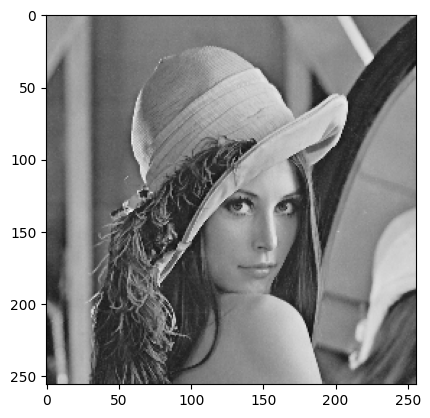

In [10]:
plt.imshow(image, cmap='gray')

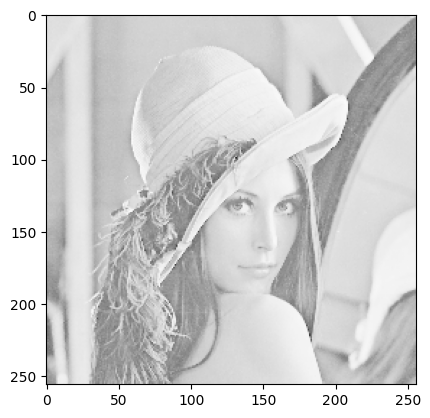

In [11]:
c=255/np.log(1+np.max(image))
log_img=np.zeros_like(image)
for i in range(image.shape[0]):
    for j in range(image.shape[1]):
        log_img[i][j]=c*np.log(1+image[i][j])
        
plt.imshow(log_img, cmap='gray')

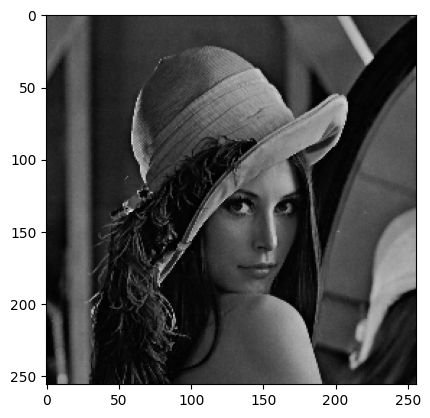

In [39]:
gamma=2.2
gamma_img=np.zeros_like(image)
for i in range(image.shape[0]):
    for j in range(image.shape[1]):
        gamma_img[i][j]=255*(image[i][j]/255)**gamma
plt.imshow(gamma_img, cmap='gray')


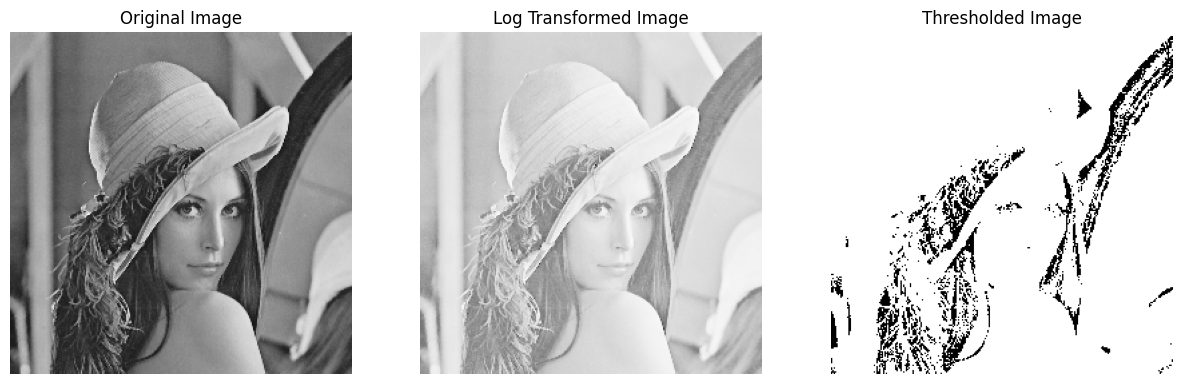

In [13]:
thres_img=log_img.copy()
for i in range (image.shape[0]):
    for j in range(image.shape[1]):
        if log_img[i][j] >180:
            thres_img[i][j]=255
        else:
            thres_img[i][j]=0
plt.figure(figsize=(15, 5))
plt.subplot(1,3,1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(log_img, cmap='gray')
plt.title('Log Transformed Image')
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(thres_img, cmap='gray')
plt.title('Thresholded Image')
plt.axis('off')
plt.show()

Question 3: Histogram Equalization and Analysis

Write a Python script to improve an image's contrast using histogram equalization and visualize the effect.

    Read a grayscale image named unequalized.jpg.

    Display the original image and plot its corresponding histogram.

    Perform Histogram Equalization on the image using cv2.equalizeHist().

    Display the equalized image and plot its new histogram.

    Arrange the outputs so that the original image is next to its histogram, and the equalized image is next to its histogram.

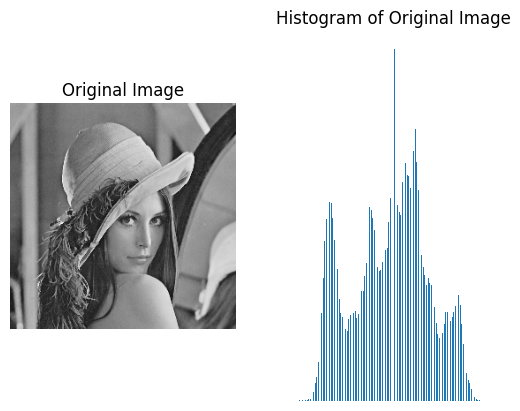

In [34]:
plt.subplot(1,2,1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.subplot(1,2,2)
plt.hist(image.flatten(),bins=256,range=[0,255])
plt.title('Histogram of Original Image')
plt.axis('off')
plt.show()

In [24]:
unique, counts = np.unique(image, return_counts=True)
total_pixels = image.size
pdf = counts / total_pixels
cdf = np.cumsum(pdf)*255

eq_cdf=np.round(cdf).astype(np.uint8)
import pandas as pd

pixel_table = pd.DataFrame({
    'values': unique,
    'occurrence': counts,
    'PDF': pdf,
    'CDF': cdf,
    'Equalized' : eq_cdf
})




In [25]:
pixel_table

,values,occurrence,PDF,CDF,Equalized
0,4.0,1,0.000015,0.003891,0
1,8.0,1,0.000015,0.007782,0
2,10.0,4,0.000061,0.023346,0
3,12.0,2,0.000031,0.031128,0
4,14.0,6,0.000092,0.054474,0
...,...,...,...,...,...
115,237.0,1,0.000015,254.972763,255
116,239.0,2,0.000031,254.980545,255
117,245.0,2,0.000031,254.988327,255
118,247.0,1,0.000015,254.992218,255


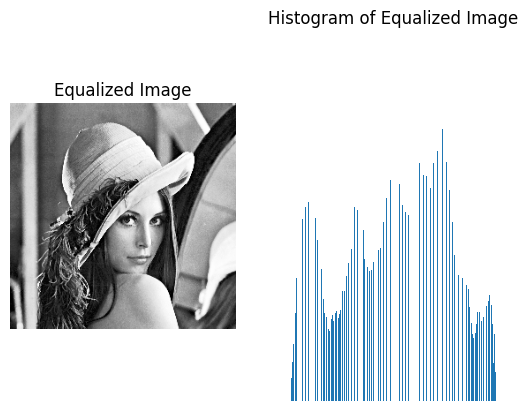

In [29]:
eq_img = np.zeros_like(image, dtype=np.uint8)
for i in range(image.shape[0]):
    for j in range(image.shape[1]):
        eq_img[i][j] = eq_cdf[np.where(unique == image[i][j])[0][0]]

plt.subplot(1,2,1)
plt.imshow(eq_img, cmap='gray')
plt.title('Equalized Image')
plt.axis('off')
plt.subplot(1,2,2)
plt.hist(eq_img.flatten(),bins=256,range=[0,255])
plt.title('Histogram of Equalized Image')
plt.axis('off')
plt.show()


Question 4: Noise Removal with Spatial Filters

Your task is to denoise an image corrupted with salt-and-pepper noise using different spatial filters and compare their performance.

    Read an image named noisy_image.png.

    Apply a 5x5 Average (Mean) filter to the noisy image.

    Apply a 5x5 Median filter to the noisy image.

    Apply a Weighted Average filter using a 3x3 Gaussian kernel (cv2.GaussianBlur).

    Display the original noisy image alongside the results from the Average, Median, and Gaussian filters for comparison. Add titles to identify which filter was used for each output.

In [50]:
image = cv2.imread('../Images/lena_color.jpg', cv2.IMREAD_GRAYSCALE)

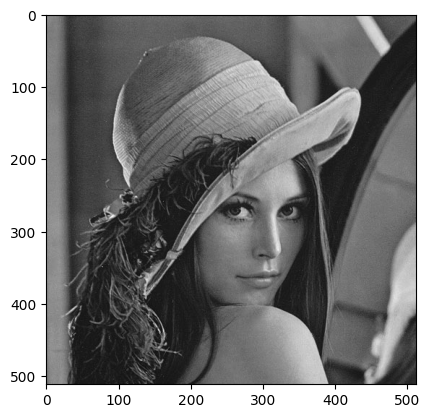

In [51]:
plt.imshow(image, cmap='gray')

In [56]:
image.shape

(512, 512)

In [52]:
def convolution(image, kernel):
 
    img_height, img_width = image.shape
    kernel_height, kernel_width = kernel.shape
    
    # Calculate padding
    pad_h = kernel_height // 2
    pad_w = kernel_width // 2
    
    # Pad the image with zeros
    padded_image = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=0)
    
    # Initialize output image
    output = np.zeros_like(image, dtype=np.float32)
    
    # Perform convolution
    for i in range(img_height):
        for j in range(img_width):
            # Extract the region of interest
            roi = padded_image[i:i+kernel_height, j:j+kernel_width]
        
            # Apply kernel (element-wise multiplication and sum)
            output[i, j] = np.sum(roi * kernel)
    
    return output

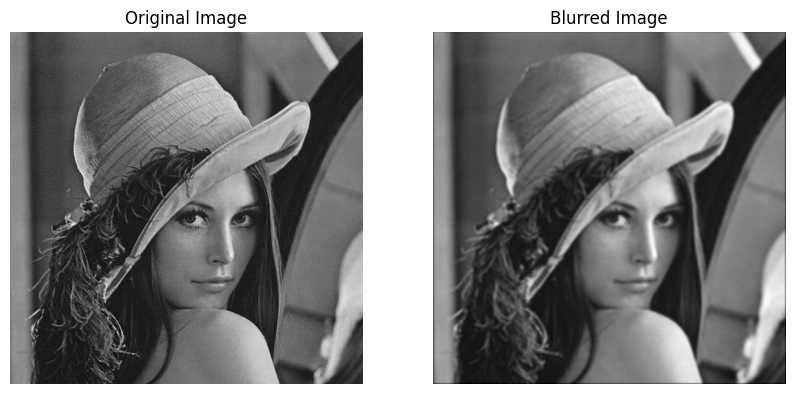

In [55]:
def avg_filter(image):
    kernel =np.ones((5, 5), dtype=np.float32) / 25.0
    
    result = convolution(image, kernel)
    result = np.clip(result, 0, 255).astype(np.uint8)
    return result

blurred_image = avg_filter(image)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(blurred_image, cmap='gray')
plt.title('Blurred Image')
plt.axis('off')
plt.show()


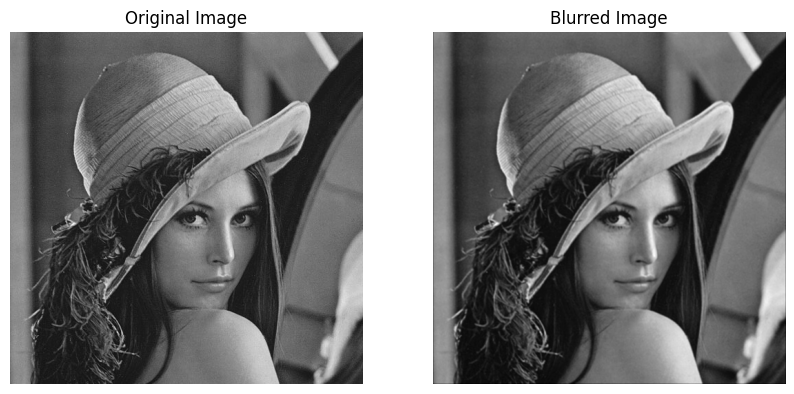

In [57]:
def weighted_avg_filter(image):
    kernel = np.array([[1, 2, 1],
                       [2, 4, 2],
                       [1, 2, 1]], dtype=np.float32) / 16.0

    result = convolution(image, kernel)
    result = np.clip(result, 0, 255).astype(np.uint8)
    return result

blurred_image = weighted_avg_filter(image)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(blurred_image, cmap='gray')
plt.title('Blurred Image')
plt.axis('off')
plt.show()

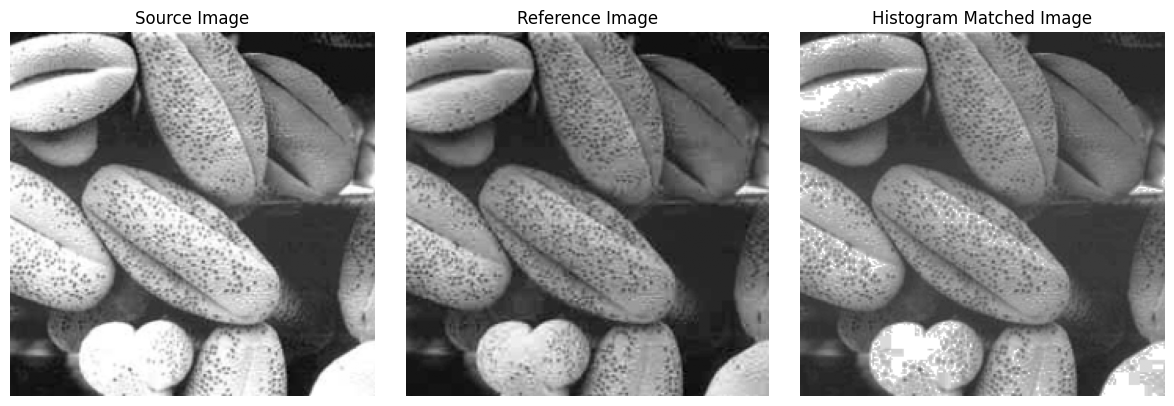

In [60]:

# Step 1: Load grayscale images
reference = cv2.imread("..\Images\Dark.PNG", cv2.IMREAD_GRAYSCALE)
source = cv2.imread("..\Images\Bright.PNG", cv2.IMREAD_GRAYSCALE)

# Step 2: Compute histograms
src_hist, _ = np.histogram(source.flatten(), bins=256, range=[0, 256])
ref_hist, _ = np.histogram(reference.flatten(), bins=256, range=[0, 256])

# Step 3: Compute normalized CDFs
src_cdf = np.cumsum(src_hist) / np.sum(src_hist)
ref_cdf = np.cumsum(ref_hist) / np.sum(ref_hist)

# Step 4: Create a lookup table for pixel mapping
lookup_table = np.zeros(256, dtype=np.uint8)
for i in range(256):
    # Find the reference intensity with the closest CDF value
    diff = np.abs(ref_cdf - src_cdf[i])
    lookup_table[i] = np.argmin(diff)

# Step 5: Apply mapping to source image
matched = lookup_table[source]

# Step 6: Display results
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(source, cmap='gray')
plt.title('Source Image')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(reference, cmap='gray')
plt.title('Reference Image')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(matched, cmap='gray')
plt.title('Histogram Matched Image')
plt.axis('off')

plt.tight_layout()
plt.show()


Question 5: Image Sharpening and Edge Detection

Write a script to perform image sharpening using a High Boost filter and edge detection using the Sobel operator.

    Read an image named structure.png and convert it to grayscale.

    Part A: Sharpening

        Create a High Boost filtered image. To do this, create a blurred version of the image (e.g., with a Gaussian filter), subtract it from the original to get a "detail" mask, and add this mask back to the original image with a weight (k) of 1.5.

    Part B: Edge Detection

        On the original grayscale image, apply the Sobel operator to find the gradients in the x and y directions.

        Combine these gradients to get the final edge magnitude image.

    Display the original image, the sharpened image from Part A, and the Sobel edge image from Part B

In [61]:
def convolution(image, kernel):
 
    img_height, img_width = image.shape
    kernel_height, kernel_width = kernel.shape
    
    # Calculate padding
    pad_h = kernel_height // 2
    pad_w = kernel_width // 2
    
    # Pad the image with zeros
    padded_image = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=0)
    
    # Initialize output image
    output = np.zeros_like(image, dtype=np.float32)
    
    # Perform convolution
    for i in range(img_height):
        for j in range(img_width):
            # Extract the region of interest
            roi = padded_image[i:i+kernel_height, j:j+kernel_width]
        
            # Apply kernel (element-wise multiplication and sum)
            output[i, j] = np.sum(roi * kernel)
    
    return output


High-boost Filter with k = 1.5
Formula: Original + k * (Original - Blurred)


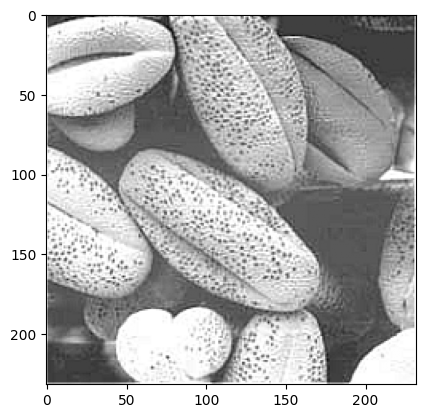

In [63]:
# Filter 5: High-boost Filter (3x3)
def highboost_filter(image, k=1.5):


    avg_kernel = np.ones((3, 3)) / 9
    blurred = convolution(image, avg_kernel)

    # Calculate high-frequency component
    high_freq = image.astype(np.float64) - blurred

    # Apply high-boost formula
    result = image.astype(np.float64) + k * high_freq

    print(f"High-boost Filter with k = {k}")
    print("Formula: Original + k * (Original - Blurred)")

    # Clip values to valid range
    result = np.clip(result, 0, 255)
    return result.astype(np.uint8)

# Apply High-boost Filter
highboost_filtered = highboost_filter(source, k=1.5)

plt.imshow(highboost_filtered, cmap='gray')

In [64]:
def normalize(image):
    min_val = np.min(image)
    max_val = np.max(image)
    if max_val == min_val:
        return np.zeros_like(image)
    return ((image - min_val) / (max_val - min_val) * 255).astype(np.uint8)

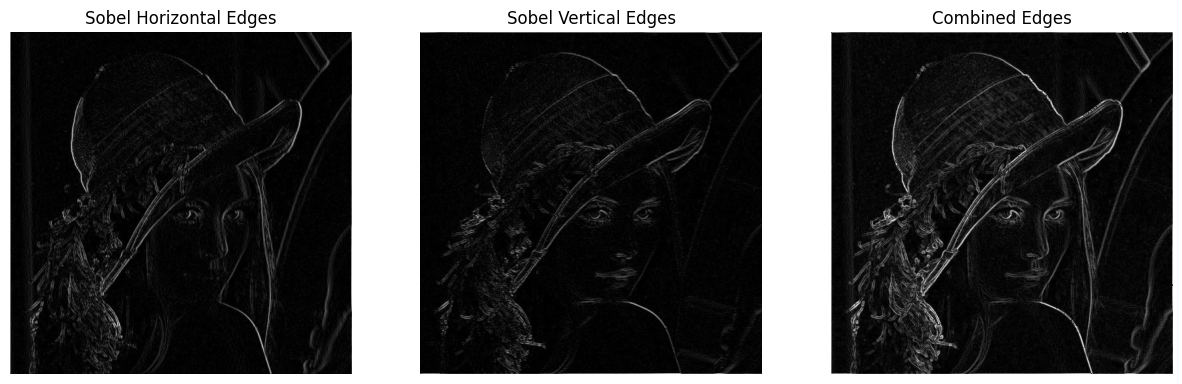

In [66]:
sobel_h =np.array([[-1, 0, 1],
                  [-2, 0, 2],
                  [-1, 0, 1]])
sobel_v = np.array([[1, 2, 1],
                   [0, 0, 0],
                   [-1, -2, -1]])

edge_h = convolution(image, sobel_h)
edge_v = convolution(image, sobel_v)

edge_h = np.abs(edge_h)
edge_v = np.abs(edge_v)

norm_edge_h = normalize(edge_h)
norm_edge_v = normalize(edge_v)

plt.figure(figsize=(15, 5))
plt.subplot(1,3,1)
plt.imshow(norm_edge_h, cmap='gray')
plt.title('Sobel Horizontal Edges')
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(norm_edge_v, cmap='gray')
plt.title('Sobel Vertical Edges')
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(np.clip(norm_edge_h + norm_edge_v, 0, 255), cmap='gray')
plt.title('Combined Edges')
plt.axis('off')
plt.show()